# T023 · 什么是激酶？

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Dominique Sydow, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Talia B. Kimber, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Jaime Rodríguez-Guerra, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)


## 本教程的目标

在本教程中，我们将讨论激酶：它们为什么在生命和药物设计中如此重要，它们长什么样，以及有哪些数据资源可用？

最后，我们选择一组激酶，这些激酶将在后续教程（T024-T028）中进行不同角度的相似性分析。


### _理论_ 部分内容

- 激酶简介
    - 人类激酶组
    - 激酶结构和重要基序
- 激酶资源
    - 激酶结构及相关信息
    - 生物活性数据
- 激酶相似性：脱靶效应和混杂结合


### _实践_ 部分内容

- 定义目标激酶


### 参考文献

- 激酶作为药物靶点：[<i>Nat. Rev. Drug Discov.</i> (2021), <b>20(7)</b>, 551-569](https://doi.org/10.1038/s41573-021-00195-4)
- 基于序列的激酶聚类：Manning et al. [<i>Science</i> (2002), <b>298(5600)</b>, 1912-1934](https://doi.org/10.1126/science.1075762)
- KLIFS 数据库：[<i>Nucleic Acid Res.</i> (2020), <b>49(D1)</b>, D562-D569](https://doi.org/10.1093/nar/gkaa895)
- 激酶数据集（kinodata）：[GitHub](https://github.com/openkinome/kinodata) 和 [出版信息](https://zenodo.org/record/3994248)
- KinMap 项目：[<i>Nucleic Acid Res.</i> (2016), <b>44(W1)</b>, W530-W535](https://doi.org/10.1093/nar/gkw418)
- 关于激酶相似性和选择性的综述：[<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 23
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 激酶简介


激酶是抗击癌症和炎症性疾病的既定药物靶点（[<i>Nat. Rev. Drug Discov.</i> (2021), <b>20(7)</b>, 551-569](https://doi.org/10.1038/s41573-021-00195-4)）。它们通过磷酸化蛋白质底物参与细胞生活的大部分方面。激酶负责将 ATP 的末端磷酸基团转移到其底物蛋白的特定丝氨酸、苏氨酸或酪氨酸残基上。活性的失调可能通过过度激活生长刺激信号而导致癌症；因此，许多激酶抑制剂已被批准为上市药物或正处于临床试验阶段。


#### 人类激酶组

人类激酶组由超过 500 种蛋白激酶组成，但这个数量可能因数据资源而异（参见 [Kinodata 概览](https://github.com/openkinome/kinodata/blob/master/human-kinases/human_kinases.ipynb)）。激酶根据其催化结构域的序列相似性分为九个组（图 1）。在本教程中，我们将介绍 TK（酪氨酸激酶）和 TKL（酪氨酸激酶样激酶）组中的一些激酶，这些组与 AGC、CAMK、CK1、CMGC、RGC、STE 和 atypical 组一起构成了人类激酶组。

![每个激酶的 PDB 结构数量](images/kinmap_n_structures_per_kinase.png)

*图 1*：激酶组树：激酶根据其序列相似性进行分组。图片改编自 Manning *et al.*, [*Science* (2002)](https://doi.org/10.1126/science.1075762)。


#### 激酶结构和重要基序

激酶序列和结构是高度保守的。激酶口袋中的重要区域包括（见图 2）：

- 铰链区（Hinge region）：与配体形成关键的氢键。
- DFG 基序：根据侧链构象在苯丙氨酸和天冬氨酸之间翻转（DFG-in 和 DFG-out）。
- αC 螺旋：在活性（螺旋-in）和非活性（螺旋-out）状态之间转换。

![激酶结构](images/T023_kinase_structure.png)

*图 2*：CDK2 激酶结构（黄色为 P-loop，红色为 αC-螺旋，蓝色为铰链区，绿色为 DFG 基序，橙色为 A-loop）。图片由 Dominique Sydow 提供。


### 激酶资源

对这个蛋白质家族的关注导致了大量关于化合物、生物活性和结构的免费可用数据，这些数据被用于计算药物开发（[<i>Annual Reports in Medicinal Chemistry</i> 50 (2017)](https://doi.org/10.1016/bs.armc.2017.08.001)）。以下是一些通常用于激酶数据的数据库：

* PDB（蛋白质结构）
* KLIFS（激酶结构，结合口袋定义和相互作用指纹）
* ChEMBL（生物活性数据）
* KinMap（激酶组树可视化）



*图 3*：一些重要的激酶相关数据资源在以下三个层面运作：结构数据（PDB 和 KLIFS）、生物活性数据（ChEMBL）和可视化（KinMap）。*PDB* 是一种蛋白质结构数据库；*KLIFS* 是一种激酶特定结构数据库，提供关于激酶口袋的详细信息，包括相互作用指纹；*ChEMBL* 包含配体及其靶标的生物活性数据；*KinMap* 提供了将任何激酶相关数据映射到激酶组树上的可能性。


#### 激酶结构及相关信息：KLIFS


KLIFS 数据库（[<i>Nucleic Acid Res.</i> (2020), <b>49(D1)</b>, D562-D569](https://doi.org/10.1093/nar/gkaa895)、[<i>J. Med. Chem.</i> (2014), <b>57(2)</b>, 249-277](https://doi.org/10.1021/jm400378w)）获取沉积在 PDB 中的所有激酶结构，并进行后处理（例如，注释激酶特定号码（KLIFS 口袋残基编号，见 **教程 T024**）、计算相互作用指纹（**教程 T026**）等）。


在 KLIFS 中，每个结构、激酶和配体都与一个标识符关联（我们将在后续教程中经常使用这些标识符）：

- 结构 KLIFS ID
- 激酶 KLIFS ID
- 配体 KLIFS ID


KLIFS 不仅包含激酶结构及其口袋定义（用于 **教程 T024 和 T025**），还包含许多结构、激酶和/或配体相关的数据：

- 相互作用指纹（用于 **教程 T026**）
- 结构质量数据（分辨率、释放日期等）
- 基于序列的激酶分类（激酶组、家族等）
- 结合相互作用（K<sub>i</sub>、IC<sub>50</sub>、pIC<sub>50</sub> 等）

有关更多信息，请参阅 [KLIFS 网站](https://klifs.net/)。


#### 生物活性数据

[ChEMBL](https://www.ebi.ac.uk/chembl/) 是一个众所周知的生物活性数据库，它会不时发布更新版本。截至 2021 年 9 月，该数据库中存储了超过 200 万个化合物和 14,000 个靶点。在 ChEMBL29 中，有超过 160,000 条关于激酶的测量数据（参见图 4）。

- `kinodata` GitHub 仓库：https://github.com/openkinome/kinodata
- `kinodata` ChEMBL29 发布版：https://github.com/openkinome/kinodata/releases/tag/v0.3（`activities-chembl29_v0.3.zip`）

与其他数据类型一样，生物活性数据在不同人类激酶之间的覆盖范围非常不均衡，这取决于对某些激酶的研究投入程度。

![每个激酶的 ChEMBL 活性数量（KinMap）](images/kinmap_n_activities_per_kinase.png)

*图 4*：使用 KinMap 将每个激酶的 ChEMBL29 生物活性数量映射到 Manning 激酶组树上。请参阅附录了解如何生成此 KinMap 树。
<!---
我们使用的是 KLIFS 激酶名称；有些名称 KinMap 无法识别，因此被略去！
--->


然而，ChEMBL 并不是唯一可用的生物活性数据库。以下是非详尽的可用激酶分析数据集列表。

- Karaman *et al.* 数据集
    - 论文：[<i>Nature Biotechnology</i> (2008), <b>26</b>, 127-132](https://doi.org/10.1038/nbt1358)
    - 317 种激酶 × 38 种化合物的相互作用组图谱
- Davis *et al.* 数据集
    - 论文：[<i>Nature Biotechnology</i> (2011), <b>29</b>, 1046-1051](https://doi.org/10.1038/nbt.1990)
    - 385 种激酶 × 72 种化合物相互作用组图谱
- Metz *et al.* 数据集
    - 论文：[<i>Nat. Chem. Biol.</i> (2011), <b>7</b>, 200-202](https://doi.org/10.1038/nchembio.530)
    - 100 种激酶 × 150 种化合物
- OpenKinome 项目收集的数据集
    - 网站：[Kinodata](https://github.com/openkinome/kinodata)
    - 已发表的激酶分析数据集的收集


### 激酶相似性：脱靶效应和混杂结合

如前所述，激酶是高度保守的，尤其是在它们的结合位点中。这种高度的相似性是药物设计中的一个挑战，因为配体可能不仅与其预期的靶标（on-target）形成相似的结合模式，还会与其他靶标（off-target）形成，从而导致脱靶效应。这种混杂的结合可能引起轻度到严重的副作用。

预测这些副作用并非易事，因为某些脱靶靶点并不明显。例如，EGFR 抑制剂 Erlotinib 对序列高度相似的 TK 激酶组中的其他激酶也表现出亲和力。然而，它还强烈影响更远缘激酶组中的脱靶靶点 GAK、LOK 和 SLK（图 5）。

![Karaman 数据集的 Erlotinib 分析数据（KinMap）](images/kinmap_erlotinib_karaman.png)

*图 5*：EGFR 抑制剂 Erlotinib 对 Karaman *et al.* 数据集的分析数据（[<i>Nature Biotechnology</i> (2008), <b>26</b>, 127-132](https://doi.org/10.1038/nbt1358)），使用 [KinMap](http://www.kinhub.org/kinmap/) 映射到 Manning 激酶组树上。请参阅本 notebook 的附录了解如何生成此图。


在接下来的四个教程（即 **教程 T024-T027**）中，我们将从不同角度评估激酶相似性，并在 **教程 T028** 中对它们进行比较：

- **教程 T024**：基于 KLIFS 口袋序列的激酶相似性
- **教程 T025**：基于 KLIFS 结构 KC 分数的激酶相似性（Kissim）
- **教程 T026**：基于 KLIFS 相互作用指纹的激酶相似性
- **教程 T027**：基于 ChEMBL 配体谱的激酶相似性
- **教程 T028**：激酶相似性视角比较


### 激酶数据集编制


在激酶相似性教程系列（**教程 T024-T028**）中，我们将使用来自 [<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629) 发表研究中的九种激酶，选择这些激酶基于以下原因：

- **EGFR** 和 **ErbB2/HER2**：重要的抗癌药物靶点，两者都属于同一蛋白质家族（ErbB 家族）。
- **CDK2** 和 **CDK4**：重要的抗癌药物靶点，两者都是细胞周期蛋白依赖性激酶。
- **AurA** 和 **AurB**：有丝分裂过程的调节因子，两者都是 Aurora 激酶。
- **IGF1R** 和 **INSR**：代谢过程的调节因子，具有高度同源的激酶结构域。
- **p38α**：丝裂原活化蛋白激酶（MAPK）信号通路的调节因子。

图 4 展示了这些激酶在激酶组树中的位置。所选激酶（带有相应激酶组别背景颜色）覆盖了多个不同的组（TK 中的 EGFR/ErbB2/IGF1R/INSR，CMGC 中的 CDK2/CDK4/p38α，以及 Others 中的 AurA/AurB）。在序列相似性方面，我们预期同一亚家族的激酶（例如 EGFR/ErbB2 或 CDK2/CDK4）在高相似性水平下聚类在一起。相反，属于不太相关激酶组的激酶预计具有较低的相似性。



*图 4*：所选激酶（颜色编码）在激酶组树中的位置。有关所选激酶的更多信息，请参见表 1。


## 实践


In [2]:
from pathlib import Path

import pandas as pd

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 定义目标激酶


我们已将关于这九种激酶的信息收集在 CSV 文件 `T023_what_is_a_kinase/data/kinase_selection.csv` 中：

- `kinase`：激酶名称，与 [<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629) 中使用的名称一致
- `kinase_klifs`：激酶的 KLIFS 名称
- `kinase_family`：激酶所属家族
- `kinase_group`：激酶所属组别
- `uniprot_id`：UniProt 标识符


In [4]:
kinase_selection_df = pd.read_csv(DATA / "kinase_selection.csv")
kinase_selection_df
# NBVAL_CHECK_OUTPUT

,kinase,kinase_klifs,uniprot_id,group,full_kinase_name
0,EGFR,EGFR,P00533,TK,Epidermal growth factor receptor
1,ErbB2,ErbB2,P04626,TK,Erythroblastic leukemia viral oncogene homolog 2
2,PI3K,p110a,P42336,Atypical,Phosphatidylinositol-3-kinase
3,VEGFR2,KDR,P35968,TK,Vascular endothelial growth factor receptor 2
4,BRAF,BRAF,P15056,TKL,Rapidly accelerated fibrosarcoma isoform B
5,CDK2,CDK2,P24941,CMGC,Cyclic-dependent kinase 2
6,LCK,LCK,P06239,TK,Lymphocyte-specific protein tyrosine kinase
7,MET,MET,P08581,TK,Mesenchymal-epithelial transition factor
8,p38a,p38a,Q16539,CMGC,p38 mitogen activated protein kinase alpha


我们将在所有后续教程中加载此数据集，从不同角度评估激酶相似性。


_注意_：您可以使用自己的一组激酶运行激酶相似性 **教程 T024-T028**。为此，请更新以下文件：

- 使用您的激酶更新 `T023_what_is_a_kinase/data/kinase_selection.csv` 文件；唯一必需的列是 `kinase` 和 `kinase_klifs`。
- 可选：如果某个激酶在 KLIFS 中不存在，请在 [KLIFS 反馈表](https://klifs.net/contact.php) 中提交新的激酶结构，或者如果由 KLIFS 分配的激酶名称与数据库中的不同，请调整 `kinase_klifs`。


In [5]:
pd.options.display.max_colwidth = None
configs = pd.read_csv(DATA / "pipeline_configs.csv")
configs

,variable,default_value,description
0,DEMO,1,Run the notebooks exactly as displayed online (default: 1) or set to 0 and run your own kinase set (as defined in `kinase_selection.csv`)
1,N_STRUCTURES_PER_KINASE,-1,Run structure-based notebooks on all structures per kinase (default: -1) or a subset of structures (replace -1 with e.g. 3)
2,N_CORES,1,Run T025 on one (default: 1) or more cores


## 附录


### KinMap 数据

本 notebook 中展示了一些 KinMap 树。以下代码生成用于上传到 KinMap 的 KinMap CSV 文件：http://www.kinhub.org/kinmap。

_注意_：
1. PNG 下载似乎已不再有效，因此请下载为 SVG 格式，然后使用 Safari 或其他浏览器打开 SVG 文件，以进一步编辑或导出为其他格式（例如 PDF）。
2. CSV 文件应保存到 `T023 目录`，以便通过引用上传；此外，CSV 文件之间由空行分隔。


In [6]:
def format_for_kinmap(kinase_names, kinase_values, size_min=10, size_max=50):
    """
    给定激酶名称和一些关联值，生成 KinMap 数据文件，该文件将以 [`size_min`, `size_max`] 尺寸的圆圈显示这些值。

    Parameters
    ----------
    kinase_names : list of str
        Kinase names.
    kinase_values : list of float
        Some associated values, such as the number of bioactivites.
    size_min : int
        Minimum circle size on KinMap tree (minimum input value will be scaled to `size_min`).
    size_max : int
        Maximum circle size on KinMap tree (maximum input value will be scaled to `size_min`).

    Returns
    -------
    pandas.DataFrame
        KinMap data with columns `xName` (kinase name), `size` (circle size for KinMap tree).
    """

    data = pd.DataFrame({"xName": kinase_names, "values": kinase_values})
    min_ = data["values"].min()
    max_ = data["values"].max()
    data["size"] = data["values"].apply(
        lambda x: ((x - min_) / (max_ - min_) * size_max) + size_min
    )
    return data[["xName", "size"]]

#### 每个激酶的 PDB 结构数量

生成每个激酶的结构数量，以 KinMap 格式映射到激酶组树上。


In [7]:
from opencadd.databases.klifs import setup_remote

klifs = setup_remote()
structures_df = klifs.structures.all_structures()

# 获取每个激酶的结构数量
n_structures_per_kinase = (
    structures_df.groupby(["structure.pdb_id", "kinase.klifs_name"])
    .first()
    .reset_index()
    .groupby("kinase.klifs_name")
    .size()
)

# Save in KinMap format
kinmap_n_structures_per_kinase = format_for_kinmap(
    n_structures_per_kinase.index, n_structures_per_kinase.values
)
kinmap_n_structures_per_kinase.to_csv(DATA / "kinmap_n_structures_per_kinase.csv", index=None)
# Some kinases will not be resolved in KinMap and will be simply dropped

识别具有最多结构的激酶。


In [8]:
kinmap_n_structures_per_kinase.iloc[n_structures_per_kinase.argmax()].xName, max(
    n_structures_per_kinase
)

('CDK2', 457)

#### 每个激酶的 ChEMBL 生物活性数量

生成每个激酶的 ChEMBL 生物活性数量，以 KinMap 格式映射到激酶组树上。


_注意_：以下单元格的执行需要几秒钟。


In [9]:
from opencadd.databases.klifs import setup_remote

# 获取生物活性数据
path = "https://github.com/openkinome/kinodata/releases/download/v0.3/activities-chembl29_v0.3.zip"
data = pd.read_csv(path, index_col=None)
data = data[data["activities.standard_type"] == "pIC50"]
data = data.dropna()

# Get kinase data
klifs = setup_remote()
kinases_df = klifs.kinases.all_kinases()
kinases_df = kinases_df[kinases_df["kinase.uniprot"] != "0"]
# Some UniProt IDs have several names in KLIFS, keep only first
kinases_df = kinases_df.groupby("kinase.uniprot").first()

# Map UniProt ID > kinase KLIFS name
data = pd.merge(data, kinases_df, left_on="UniprotID", right_on="kinase.uniprot", how="left")

# Get number of activities per kinase
n_activities_per_kinase = data.groupby("kinase.klifs_name").size()

# Save in KinMap format
kinmap_n_activities_per_kinase = format_for_kinmap(
    n_activities_per_kinase.index, n_activities_per_kinase.values
)
kinmap_n_activities_per_kinase.to_csv(DATA / "kinmap_n_activities_per_kinase.csv", index=None)
# Some kinases will not be resolved in KinMap and will be simply dropped

#### Karaman *et al.* 数据集的 Erlotinib 分析数据

- 前往 http://www.kinhub.org/kinmap/
- 选择"Data Source"（数据源）：Profiling
- 选择"Data type"（数据类型）：Karaman et al., 2018
- 选择 "Karaman et al., 2018"：Erlotinib
- 点击 "Add source"（添加源）
- 在 **设置** 菜单中，将颜色映射更改为（例如）红色


### 使用 `opencadd` 进行激酶结构可视化

我们使用 KLIFS ID 为 [4367](https://klifs.net/details.php?structure_id=4367) 的 ATP 结合 CDK2 结构作为示例。


In [10]:
from opencadd.structure.pocket import PocketKlifs, PocketViewer

# Get structure and pocket
pocket = PocketKlifs.from_structure_klifs_id(4367)

# Show pocket
viewer = PocketViewer()
viewer.add_pocket(pocket, ligand_expo_id="ATP", show_pocket_center=False)
viewer.viewer.add_ball_and_stick(selection="ATP")
viewer.viewer

NGLWidget()

In [11]:
viewer.viewer.render_image(trim=True, factor=2);

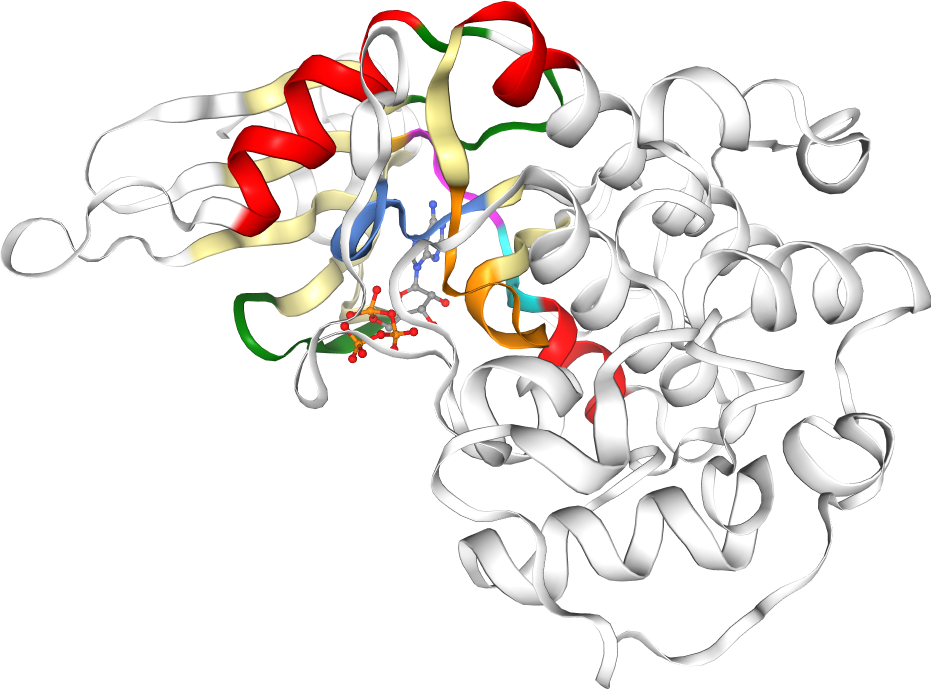

In [13]:
viewer.viewer._display_image()